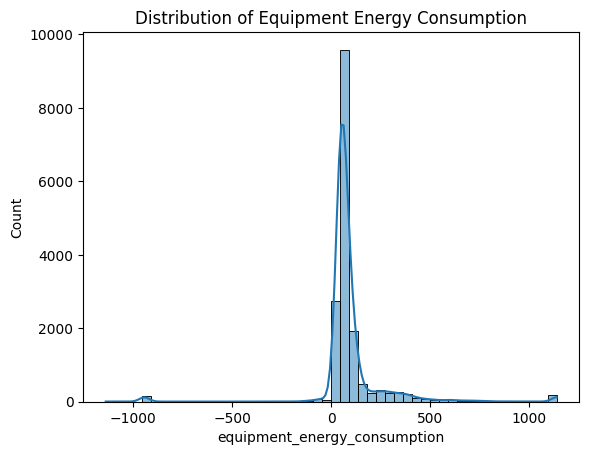

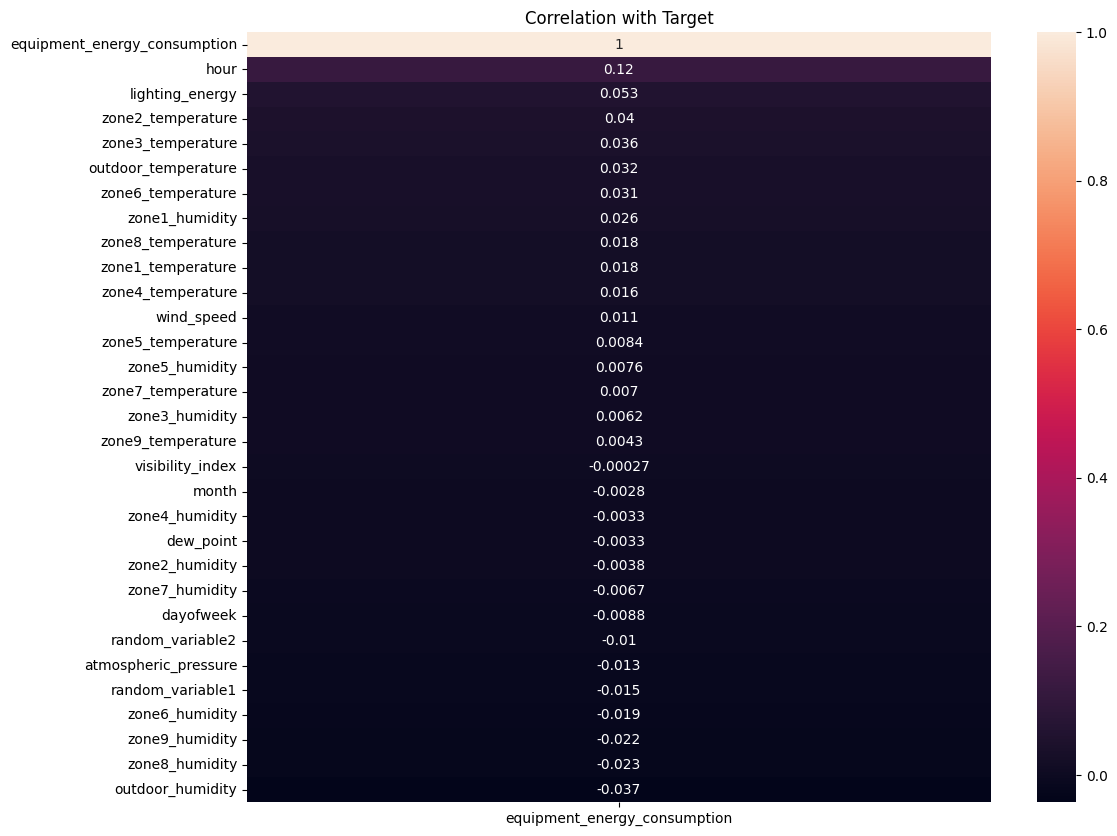


Model Performance:

                        RMSE        MAE        R2
RandomForest      173.821840  71.644039  0.063667
LinearRegression  178.040700  74.333062  0.017664
XGBoost           184.442926  85.399218 -0.054255


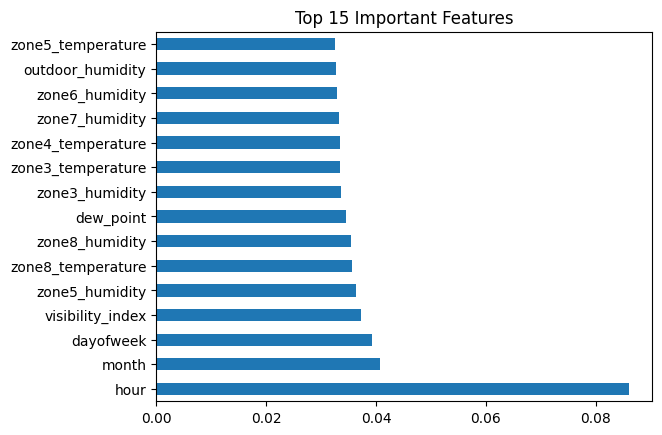


All deliverables saved: predictions CSV and summary markdown report.


In [1]:
# Smart Factory Energy Forecasting
# 1. Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# Load data
df = pd.read_csv("/content/data.csv")


# 2. Data Cleaning

# Fix column types
for col in df.columns:
    if df[col].dtype == 'object' and col != 'timestamp':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Missing value summary
missing_summary = df.isnull().sum().sort_values(ascending=False)

# Impute missing values with median
imputer = SimpleImputer(strategy="median")
df.iloc[:, 1:] = imputer.fit_transform(df.iloc[:, 1:])


# 3. Feature Engineering

# Time features
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Drop timestamp (can re-add later if needed)
df.drop(columns=['timestamp'], inplace=True)


  # 4. EDA (Basic Visuals)

  sns.histplot(df['equipment_energy_consumption'], bins=50, kde=True)
  plt.title('Distribution of Equipment Energy Consumption')
  plt.show()

  corr = df.corr()
  plt.figure(figsize=(12, 10))
  sns.heatmap(corr[['equipment_energy_consumption']].sort_values(by='equipment_energy_consumption', ascending=False), annot=True)
  plt.title("Correlation with Target")
  plt.show()


  # 5. Modeling

  # Define X and y
  X = df.drop(columns=['equipment_energy_consumption'])
  y = df['equipment_energy_consumption']

  # Train-test split
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Scale features
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # Models
  models = {
      'LinearRegression': LinearRegression(),
      'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
      'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42)
  }

  results = {}

  for name, model in models.items():
      model.fit(X_train_scaled, y_train)
      y_pred = model.predict(X_test_scaled)
      results[name] = {
          'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
          'MAE': mean_absolute_error(y_test, y_pred),
          'R2': r2_score(y_test, y_pred)
      }


# 6. Model Evaluation Summary

results_df = pd.DataFrame(results).T
print("\nModel Performance:\n")
print(results_df.sort_values(by='RMSE'))

# Feature importances from best model (XGBoost)
best_model = models['XGBoost']
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.nlargest(15).plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()


# 7. Final Prediction Output

final_preds = best_model.predict(X_test_scaled)
pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': final_preds
})
pred_df.to_csv("/content/final_predictions.csv", index=False)


# 8. Save Deliverables Summary

summary_md = f"""
# Smart Factory Energy Forecasting Summary

## Dataset Overview
- Observations: {df.shape[0]}
- Features: {df.shape[1]}
- Target: equipment_energy_consumption

## Modeling Results
{results_df.sort_values(by='RMSE').to_markdown()}

## Best Model: XGBoost
- Used for final prediction
- Feature importance plotted above

## Files Produced
- final_predictions.csv: Contains actual vs predicted energy consumption on test set
"""

with open("/content/summary_report.md", "w") as f:
    f.write(summary_md)

print("\nAll deliverables saved: predictions CSV and summary markdown report.")

# New section